---
title: "Sesi 3: Structural Equation Modelling (SEM)"
subtitle: "ISEI Workshop: Analisis Regresi & SEM dengan RStudio"
jupyter: ir
execute:
  warning: false
  message: false
---

# Pengantar SEM

### Rencana Hari Ini

**Bagian A: CB-SEM dengan `lavaan`**

- Pengantar SEM & terminologi
- Two-Step Approach: CFA → Full SEM
- Dataset E-Loyalty
- Evaluasi model: fit indices, reliabilitas, validitas
- Mediasi

**Bagian B: PLS-SEM dengan `seminr`**

- Kapan menggunakan PLS-SEM
- Dataset ECSI (mobi)
- Outer & inner model evaluation
- Bootstrap, mediasi

---

**Structural Equation Modeling (SEM)** adalah teknik statistik multivariat yang menggabungkan analisis faktor dan regresi. SEM memungkinkan pengujian hubungan simultan antara beberapa variabel, termasuk variabel **laten** (tidak langsung teramati) melalui indikator-indikator terukur.

SEM terdiri dari dua komponen:

- **Measurement model**: hubungan antara variabel laten dan indikator-indikatornya ("Seberapa baik indikator mengukur konstruk?")
- **Structural model**: hubungan antar variabel laten ("Bagaimana konstruk saling mempengaruhi?")

### Terminologi SEM

| Istilah | Penjelasan |
|---------|------------|
| **Variabel Laten** | Konstruk yang tidak dapat diukur langsung (simbol oval dalam diagram) |
| **Variabel Manifes/Indikator** | Item kuesioner atau pengukuran langsung (simbol kotak) |
| **Variabel Eksogen** | Variabel independen — tidak diprediksi oleh variabel lain dalam model |
| **Variabel Endogen** | Variabel dependen — diprediksi oleh variabel lain dalam model |

### Measurement Model vs Structural Model

- **Measurement model**: menguji hubungan antara konstruk laten dan indikator-indikatornya
  - Pertanyaan utamanya: *"Seberapa baik indikator mengukur konstruk?"*
- **Structural model**: menguji hubungan antar konstruk laten
  - Pertanyaan utamanya: *"Bagaimana konstruk saling mempengaruhi?"*

SEM penting karena mengevaluasi **kedua komponen tersebut secara terpadu**, sehingga analisis tidak hanya berhenti pada kualitas pengukuran, tetapi juga pada hubungan teoritis antar konstruk.

### Kapan Menggunakan CB-SEM vs PLS-SEM?

| Kriteria | CB-SEM | PLS-SEM |
|----------|--------|---------|
| Basis | Kovarians | Varians |
| Tujuan | Konfirmasi teori | Prediksi & eksplorasi |
| Ukuran sampel | Besar (>200) | Kecil–menengah (>50) |
| Distribusi | Memerlukan normalitas | Fleksibel |
| Tipe indikator | Reflektif | Reflektif & formatif |
| Fit indices | CFI, TLI, RMSEA, SRMR | Tidak ada (gunakan R², HTMT) |
| Paket R | `lavaan` | `seminr` |

### Two-Step Approach

**Anderson & Gerbing (1988)** merekomendasikan:

1. **Langkah 1 — CFA**: Evaluasi measurement model terlebih dahulu (validitas konvergen & diskriminan)
2. **Langkah 2 — Full SEM**: Tambahkan jalur struktural (uji hipotesis)

::: {.callout-important}
Jangan langsung menjalankan full SEM tanpa memastikan measurement model sudah baik! Jika pengukuran buruk, kesimpulan struktural tidak dapat dipercaya.
:::

---

# Bagian A: CB-SEM dengan lavaan

## 1. Persiapan

In [2]:
library(tidyverse)
library(readxl)
library(lavaan)
library(semPlot)
library(knitr)
set.seed(2026)

── Attaching core tidyverse packages ─
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ─────────────────────────
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘ggplot2’ was built under R version 4.5.3 


This is lavaan 0.6-19
lavaan is FREE software! Please report any bugs.


## 2. Import Data

Data tentang pengaruh Perceived Mental Benefits dan Hedonic Value terhadap E-Loyalty (Khoa & Nguyen, 2020).

In [3]:
dat <- read_excel("data/sem/data.xlsx")
dat <- dat |> select(-No)
glimpse(dat)

Rows: 485
Columns: 14
$ HV1        <dbl> 5, 4, 5, 5, 4, 5,…
$ HV2        <dbl> 5, 4, 4, 5, 4, 4,…
$ HV3        <dbl> 5, 4, 5, 4, 4, 5,…
$ HV4        <dbl> 5, 4, 5, 5, 4, 5,…
$ PMB1       <dbl> 4, 4, 4, 4, 5, 4,…
$ PMB2       <dbl> 4, 4, 4, 4, 4, 4,…
$ PMB3       <dbl> 4, 4, 4, 4, 5, 3,…
$ PMB4       <dbl> 4, 4, 4, 4, 4, 4,…
$ ELOY1      <dbl> 5, 4, 4, 4, 4, 5,…
$ ELOY2      <dbl> 5, 4, 4, 4, 4, 4,…
$ ELOY3      <dbl> 4, 5, 4, 4, 4, 4,…
$ gender     <dbl> 2, 2, 1, 2, 2, 1,…
$ occupation <dbl> 4, 6, 3, 5, 1, 5,…
$ times      <dbl> 3, 4, 3, 1, 4, 4,…


### Konstruk dan Indikator

| Konstruk | Indikator | Deskripsi | Referensi |
|----------|-----------|-----------|-----------|
| **PMB** (Perceived Mental Benefits) | PMB1–PMB4 | Manfaat mental yang dirasakan konsumen | Nguyen & Khoa (2019) |
| **HV** (Hedonic Value) | HV1–HV4 | Nilai hedonik dari pengalaman belanja online | Lee & Wu (2017) |
| **ELOY** (Electronic Loyalty) | ELOY1–ELOY3 | Loyalitas elektronik konsumen | Khoa & Nguyen (2020) |

Semua konstruk bersifat **reflektif** — indikator merupakan efek dari konstruk.

### Hipotesis Penelitian

| No | Hipotesis | Path |
|----|-----------|------|
| H1 | PMB berpengaruh positif terhadap ELOY | ELOY ~ PMB |
| H2 | PMB berpengaruh positif terhadap HV | HV ~ PMB |
| H3 | HV berpengaruh positif terhadap ELOY | ELOY ~ HV |

Model ini juga memungkinkan pengujian **efek mediasi** HV dalam hubungan PMB → ELOY.

### Sintaks lavaan

| Operator | Makna | Contoh |
|----------|-------|--------|
| `=~` | "diukur oleh" (measurement) | `PMB =~ PMB1 + PMB2` |
| `~` | "diregresikan terhadap" (structural) | `ELOY ~ PMB + HV` |
| `~~` | kovarians/varians | `HV ~~ ELOY` |
| `:=` | defined parameter (mediasi) | `indirect := a*b` |

Sintaks ini penting karena model SEM pada dasarnya ditulis sebagai **bahasa spesifikasi model**. Jika peserta memahami arti operator-operator ini, mereka akan jauh lebih mudah membaca maupun memodifikasi model.

## 3. CFA (Confirmatory Factor Analysis)

### Spesifikasi dan Estimasi CFA

In [4]:
cfa_model <- '
  PMB  =~ PMB1 + PMB2 + PMB3 + PMB4
  HV   =~ HV1 + HV2 + HV3 + HV4
  ELOY =~ ELOY1 + ELOY2 + ELOY3
'

cfa_fit <- cfa(cfa_model, data = dat)

Estimator default: **ML** (Maximum Likelihood). Secara otomatis menetapkan loading pertama = 1 untuk identifikasi model.

### Fit Indices CFA

In [5]:
fitMeasures(cfa_fit, c("chisq", "df", "pvalue",
                        "cfi", "tli", "rmsea", "srmr"))

  chisq      df  pvalue     cfi 
969.080  41.000   0.000   0.742 
    tli   rmsea    srmr 
  0.654   0.216   0.124 

**Interpretasi:** Fit CFA kurang memadai: CFI = 0.742 (< 0.90), TLI = 0.654 (< 0.90), RMSEA = 0.216 (> 0.08), SRMR = 0.124 (> 0.08). Model pengukuran perlu perbaikan (misalnya menghapus indikator dengan loading rendah atau menambahkan kovarians error). Untuk tujuan pembelajaran, kita tetap melanjutkan.

Kriteria fit berdasarkan **Hu & Bentler (1999)**:

| Indeks | Kriteria Baik | Keterangan |
|--------|---------------|------------|
| $\chi^2$ p-value | > 0.05 | Sensitif terhadap sampel besar |
| CFI | ≥ 0.90 | Comparative Fit Index |
| TLI | ≥ 0.90 | Tucker-Lewis Index |
| RMSEA | ≤ 0.08 | Root Mean Square Error of Approximation |
| SRMR | ≤ 0.08 | Standardized Root Mean Square Residual |

::: {.callout-tip}
Laporkan minimal CFI, RMSEA, dan SRMR. Jangan hanya mengandalkan satu indeks.
:::

Dalam praktik, jarang ada model yang sempurna pada semua indeks. Karena itu, evaluasi fit sebaiknya dilakukan secara **holistik**, bukan berdasarkan satu angka saja.

In [6]:
summary(cfa_fit)

lavaan 0.6-19 ended normally after 38 iterations

  Estimator                                         ML
  Optimization method                           NLMINB
  Number of model parameters                        25

  Number of observations                           485

Model Test User Model:
                                                      
  Test statistic                               969.080
  Degrees of freedom                                41
  P-value (Chi-square)                           0.000

Parameter Estimates:

  Standard errors                             Standard
  Information                                 Expected
  Information saturated (h1) model          Structured

Latent Variables:
                   Estimate  Std.Err
  PMB =~                            
    PMB1              1.000         
    PMB2              0.733    0.036
    PMB3              0.698    0.046
    PMB4              0.558    0.043
  HV =~                             
    HV1            

**Membaca Output `summary()` pada objek lavaan:**

Output terdiri dari beberapa bagian:

1. **Header**: Estimator yang digunakan (ML, MLR, WLSMV, dll.), metode optimasi, jumlah derajat bebas, dan jumlah observasi.

2. **Model Test User Model (Chi-square)**: Uji apakah model cocok dengan data. $p > .05$ = model fit baik. Namun chi-square sangat sensitif terhadap ukuran sampel — pada $n$ besar, hampir selalu signifikan meskipun misfit kecil. Gunakan fit indices lain sebagai pelengkap.

3. **Latent Variables (Factor Loadings)**:
   - Menunjukkan hubungan setiap indikator terhadap konstruk latennya.
   - Loading pertama setiap konstruk di-fix = 1.000 (default untuk identifikasi model; bisa diubah dengan argumen `std.lv = TRUE` agar varians laten = 1).
   - Kolom: `Estimate` (unstandardized), `Std.Err`, `z-value`, `P(>|z|)`.

4. **Covariances**: Kovarians antar konstruk laten (pada CFA) atau error terms. Pada CFA, semua konstruk secara default diizinkan berkorelasi bebas.

5. **Variances**: Baris dengan titik (`.X1`) = error variance indikator. Baris tanpa titik (`F1`) = varians konstruk laten.

::: {.callout-tip}
## Argumen Berguna pada `summary()`

| Argumen | Fungsi |
|---------|--------|
| `standardized = TRUE` | Menampilkan standardized estimates (kolom `Std.lv`, `Std.all`) |
| `fit.measures = TRUE` | Menampilkan fit indices langsung di output |
| `rsquare = TRUE` | Menampilkan $R^2$ setiap indikator/variabel endogen |
| `ci = TRUE` | Menampilkan confidence interval |

Contoh: `summary(cfa_fit, standardized = TRUE, fit.measures = TRUE, rsquare = TRUE)`
:::

### Standardized Factor Loadings

In [5]:
parameterEstimates(cfa_fit, standardized = TRUE) |>
  filter(op == "=~") |>
  select(Konstruk = lhs, Indikator = rhs,
         Loading = est, Std.Loading = std.all, p = pvalue) |>
  mutate(Memadai = ifelse(Std.Loading >= 0.50, "Ya", "Tidak")) |>
  kable(digits = 3)



|Konstruk |Indikator | Loading| Std.Loading|  p|Memadai |
|:--------|:---------|-------:|-----------:|--:|:-------|
|PMB      |PMB1      |   1.000|       0.868| NA|Ya      |
|PMB      |PMB2      |   0.733|       0.841|  0|Ya      |
|PMB      |PMB3      |   0.698|       0.652|  0|Ya      |
|PMB      |PMB4      |   0.558|       0.577|  0|Ya      |
|HV       |HV1       |   1.000|       0.828| NA|Ya      |
|HV       |HV2       |   0.991|       0.873|  0|Ya      |
|HV       |HV3       |   0.840|       0.734|  0|Ya      |
|HV       |HV4       |   1.049|       0.847|  0|Ya      |
|ELOY     |ELOY1     |   1.000|       0.908| NA|Ya      |
|ELOY     |ELOY2     |   0.741|       0.847|  0|Ya      |
|ELOY     |ELOY3     |   0.464|       0.546|  0|Ya      |

**Interpretasi:** Semua standardized loading > 0.50, menunjukkan convergent validity memadai. Loading tertinggi pada PMB1 (0.868) dan ELOY1 (0.908). ELOY3 (0.546) dan PMB4 (0.577) mendekati batas bawah — jika fit buruk, pertimbangkan penghapusan.

**Interpretasi**: Standardized loading (λ) ≥ 0.50 dianggap memadai, idealnya ≥ 0.70. Indikator dengan loading < 0.50 perlu dipertimbangkan untuk dihapus karena tidak cukup merepresentasikan konstruk.

### Composite Reliability (CR) & AVE

In [6]:
std_loadings <- parameterEstimates(cfa_fit, standardized = TRUE) |>
  filter(op == "=~") |>
  select(lhs, std.all)

reliabilitas <- std_loadings |>
  group_by(Konstruk = lhs) |>
  summarize(
    n_items = n(),
    sum_lambda = sum(std.all),
    sum_lambda2 = sum(std.all^2),
    AVE = sum(std.all^2) / n(),
    CR = sum_lambda^2 / (sum_lambda^2 + (n() - sum(std.all^2))),
    .groups = "drop"
  )
reliabilitas |> select(Konstruk, n_items, AVE, CR) |> kable(digits = 3)



|Konstruk | n_items|   AVE|    CR|
|:--------|-------:|-----:|-----:|
|ELOY     |       3| 0.613| 0.820|
|HV       |       4| 0.676| 0.893|
|PMB      |       4| 0.555| 0.829|

**Interpretasi:** AVE > 0.50 dan CR > 0.70 untuk semua konstruk — convergent validity dan reliabilitas terpenuhi. HV memiliki AVE tertinggi (0.676), menunjukkan indikator-indikatornya paling konsisten merepresentasikan konstruk.

| Kriteria | Ambang Batas | Keterangan |
|----------|-------------|------------|
| AVE | ≥ 0.50 | Convergent validity — rata-rata varians yang diekstrak |
| CR | ≥ 0.70 | Reliabilitas konstruk |

### Discriminant Validity: Fornell-Larcker

**Fornell & Larcker (1981)**: √AVE setiap konstruk harus lebih besar dari korelasi antar konstruk.

In [7]:
# Matriks korelasi antar konstruk laten
cor_lv <- lavInspect(cfa_fit, "cor.lv")

# Hitung sqrt(AVE)
ave_vals <- reliabilitas$AVE
names(ave_vals) <- reliabilitas$Konstruk
sqrt_ave <- sqrt(ave_vals)

cat("Korelasi antar konstruk:\n")
round(cor_lv, 3)

Korelasi antar konstruk:


       PMB    HV  ELOY
PMB  1.000            
HV   0.434 1.000      
ELOY 0.548 0.413 1.000

In [8]:
cat("Sqrt(AVE) per konstruk:\n")
round(sqrt_ave, 3)

Sqrt(AVE) per konstruk:


 ELOY    HV   PMB 
0.783 0.822 0.745 

**Interpretasi:** √AVE PMB (0.745) > korelasi PMB–HV (0.434) dan PMB–ELOY (0.548). √AVE HV (0.822) > korelasi HV–ELOY (0.413). Discriminant validity terpenuhi untuk semua pasangan konstruk — setiap konstruk berbeda secara empiris.

**Interpretasi**: Jika √AVE lebih besar dari semua korelasi pada baris/kolomnya, discriminant validity terpenuhi. Ini menunjukkan bahwa setiap konstruk lebih banyak berbagi varians dengan indikatornya sendiri dibanding dengan konstruk lain.

Setelah CFA memadai (measurement model baik), kita melanjutkan ke **langkah 2**: menambahkan jalur struktural. Kita mulai dengan model **tanpa mediasi** terlebih dahulu, kemudian membandingkannya dengan model mediasi.

## 4. Structural Model Tanpa Mediasi

Sebelum menguji mediasi, kita estimasi dulu model struktural **sederhana**: hanya jalur langsung dari masing-masing variabel eksogen ke variabel endogen, tanpa memodelkan efek tidak langsung.

Model ini menguji: apakah PMB dan HV masing-masing berpengaruh langsung terhadap ELOY?

In [15]:
sem_direct <- '
  # Measurement model
  PMB  =~ PMB1 + PMB2 + PMB3 + PMB4
  HV   =~ HV1 + HV2 + HV3 + HV4
  ELOY =~ ELOY1 + ELOY2 + ELOY3

  # Structural model (tanpa mediasi — hanya efek langsung)
  ELOY ~ PMB + HV
'

sem_direct_fit <- sem(sem_direct, data = dat)

In [16]:
fitMeasures(sem_direct_fit, c("chisq", "df", "pvalue",
                              "cfi", "tli", "rmsea", "srmr"))

  chisq      df  pvalue     cfi 
969.080  41.000   0.000   0.742 
    tli   rmsea    srmr 
  0.654   0.216   0.124 

In [17]:
parameterEstimates(sem_direct_fit, standardized = TRUE) |>
  filter(op == "~") |>
  select(DV = lhs, IV = rhs, B = est, SE = se, Z = z,
         p = pvalue, Beta = std.all) |>
  mutate(Sig = ifelse(p < 0.05, "Ya", "Tidak")) |>
  kable(digits = 3)



|DV   |IV  |     B|    SE|     Z|  p|  Beta|Sig |
|:----|:---|-----:|-----:|-----:|--:|-----:|:---|
|ELOY |PMB | 0.564| 0.066| 8.606|  0| 0.454|Ya  |
|ELOY |HV  | 0.275| 0.064| 4.302|  0| 0.216|Ya  |

In [18]:
lavInspect(sem_direct_fit, "r2")

 PMB1  PMB2  PMB3  PMB4   HV1   HV2 
0.754 0.708 0.426 0.333 0.685 0.763 
  HV3   HV4 ELOY1 ELOY2 ELOY3  ELOY 
0.539 0.718 0.824 0.717 0.298 0.339 

**Interpretasi Model Tanpa Mediasi:**

- PMB berpengaruh langsung terhadap ELOY ($\beta = 0.454$, $p < .001$) — pengaruh terkuat.
- HV juga berpengaruh langsung terhadap ELOY ($\beta = 0.216$, $p < .001$).
- $R^2$ ELOY = 0.339 → PMB dan HV bersama-sama menjelaskan **33.9%** varians E-Loyalty.

Model ini belum menjawab pertanyaan: *apakah PMB juga mempengaruhi ELOY secara tidak langsung melalui HV?* Untuk itu, kita perlu menambahkan jalur PMB → HV dan menguji **efek mediasi**.

## 5. Full Structural Model dengan Mediasi

Sekarang kita tambahkan jalur PMB → HV dan gunakan **label** untuk menghitung indirect effect.

In [9]:
sem_model <- '
  # Measurement model
  PMB  =~ PMB1 + PMB2 + PMB3 + PMB4
  HV   =~ HV1 + HV2 + HV3 + HV4
  ELOY =~ ELOY1 + ELOY2 + ELOY3

  # Structural model (dengan label untuk mediasi)
  HV   ~ a*PMB
  ELOY ~ c*PMB + b*HV

  # Defined parameters
  indirect := a*b
  total    := c + a*b
'

**Penjelasan label**: `a`, `b`, `c` adalah label untuk koefisien jalur. Dengan label ini, kita dapat mendefinisikan **indirect effect** (`a*b`) dan **total effect** (`c + a*b`) yang akan dihitung dan diuji secara langsung oleh lavaan.

### Estimasi Full SEM dengan Bootstrap

In [10]:
sem_fit <- sem(sem_model, data = dat, se = "bootstrap", bootstrap = 1000)

::: {.callout-note}
Bootstrap SE digunakan karena distribusi sampling efek mediasi (`a*b`) umumnya *skewed*, sehingga uji klasik seperti **Sobel test** yang mengasumsikan normalitas menjadi kurang akurat. Bootstrap menghasilkan confidence interval empiris yang lebih valid tanpa bergantung pada asumsi distribusi.
:::

### Fit Indices Full SEM

In [11]:
fitMeasures(sem_fit, c("chisq", "df", "pvalue",
                        "cfi", "tli", "rmsea", "srmr"))

  chisq      df  pvalue     cfi 
969.080  41.000   0.000   0.742 
    tli   rmsea    srmr 
  0.654   0.216   0.124 

**Interpretasi:** Fit indices Full SEM sama persis dengan CFA karena semua jalur antar 3 konstruk sudah dispesifikasikan (model struktural *saturated*). Artinya, fit yang kita lihat hanya mencerminkan kualitas pengukuran, bukan kualitas teori struktural.

::: {.callout-important}
## Apa yang Harus Dilakukan Jika Fit Buruk?

Fit indices di atas menunjukkan model **belum memadai** (CFI = 0.742, RMSEA = 0.216). Dalam praktik penelitian, langkah yang bisa diambil:

1. **Periksa modification indices** — cari kovarians error yang perlu ditambahkan:
   ```r
   modindices(cfa_fit, sort = TRUE, minimum.value = 10)
   ```
2. **Hapus indikator bermasalah** — indikator dengan loading < 0.50 atau yang menyebabkan cross-loading tinggi
3. **Tambahkan kovarians error** — hanya jika ada justifikasi teoretis (misal: dua item yang kata-katanya mirip)
4. **Pertimbangkan PLS-SEM** — jika sampel kecil atau model kompleks, PLS-SEM tidak memerlukan fit indices dan lebih fleksibel

**Jangan** memodifikasi model hanya untuk mengejar angka fit yang bagus tanpa dasar teori — ini disebut *capitalizing on chance* dan mengurangi generalizability hasil.
:::

In [14]:
mi <- modindices(cfa_fit, sort = TRUE, minimum.value = 10)
mi |> head(20) |> kable(digits = 3)



|    |lhs   |op |rhs   |      mi|    epc| sepc.lv| sepc.all| sepc.nox|
|:---|:-----|:--|:-----|-------:|------:|-------:|--------:|--------:|
|57  |PMB1  |~~ |HV4   | 134.385| -0.115|  -0.115|   -0.769|   -0.769|
|45  |ELOY  |=~ |PMB3  | 133.769| -0.492|  -0.390|   -0.571|   -0.571|
|43  |ELOY  |=~ |PMB1  | 109.088|  0.433|   0.343|    0.466|    0.466|
|35  |PMB   |=~ |ELOY3 | 106.494|  0.579|   0.370|    0.550|    0.550|
|103 |ELOY1 |~~ |ELOY2 |  93.921|  0.507|   0.507|    3.742|    3.742|
|75  |PMB3  |~~ |ELOY1 |  91.513| -0.125|  -0.125|   -0.658|   -0.658|
|66  |PMB2  |~~ |HV4   |  74.743|  0.067|   0.067|    0.540|    0.540|
|61  |PMB2  |~~ |PMB3  |  64.859|  0.092|   0.092|    0.588|    0.588|
|31  |PMB   |=~ |HV3   |  57.716| -0.343|  -0.219|   -0.307|   -0.307|
|29  |PMB   |=~ |HV1   |  55.761|  0.317|   0.203|    0.269|    0.269|
|58  |PMB1  |~~ |ELOY1 |  55.679|  0.086|   0.086|    0.640|    0.640|
|78  |PMB4  |~~ |HV1   |  43.869|  0.075|   0.075|    0.349|    0.349|
|47 

**Membaca Modification Indices:**

Kolom `mi` menunjukkan seberapa banyak chi-square akan turun jika parameter tersebut ditambahkan. Semakin besar `mi`, semakin besar potensi perbaikan fit.

Dari tabel di atas terlihat beberapa pola:

1. **Cross-loading tinggi** — beberapa indikator PMB "ingin" loading ke ELOY dan sebaliknya (mis. ELOY =~ PMB3, mi = 134; PMB =~ ELOY3, mi = 106). Ini mengindikasikan item-item tersebut tidak murni mengukur satu konstruk.
2. **Kovarians error** — PMB1 ~~ HV4 (mi = 134) dan ELOY1 ~~ ELOY2 (mi = 94) menunjukkan ada varians bersama antar indikator yang tidak dijelaskan oleh model.

::: {.callout-warning}
## Perhatian

Modification indices bersifat **data-driven**. Jangan menambahkan semua yang disarankan — hanya tambahkan yang memiliki **justifikasi teoretis**. Misalnya, kovarians error ELOY1 ~~ ELOY2 mungkin wajar jika kedua item memiliki formulasi kata yang serupa.
:::

### Path Coefficients (Uji Hipotesis)

In [12]:
parameterEstimates(sem_fit, standardized = TRUE) |>
  filter(op == "~") |>
  select(DV = lhs, IV = rhs, B = est, SE = se, Z = z,
         p = pvalue, Beta = std.all) |>
  mutate(Sig = ifelse(p < 0.05, "Ya", "Tidak")) |>
  kable(digits = 3)



|DV   |IV  |     B|    SE|     Z|  p|  Beta|Sig |
|:----|:---|-----:|-----:|-----:|--:|-----:|:---|
|HV   |PMB | 0.424| 0.080| 5.296|  0| 0.434|Ya  |
|ELOY |PMB | 0.564| 0.117| 4.823|  0| 0.454|Ya  |
|ELOY |HV  | 0.275| 0.067| 4.127|  0| 0.216|Ya  |

**Interpretasi:** Semua 3 hipotesis didukung ($p < .001$). PMB → HV ($\beta = 0.434$): H2 terdukung. PMB → ELOY ($\beta = 0.454$): H1 terdukung, efek langsung terkuat. HV → ELOY ($\beta = 0.216$): H3 terdukung. PMB memiliki pengaruh langsung yang lebih besar terhadap ELOY dibanding melalui HV.

**Interpretasi**: Kolom `Beta` (standardized) menunjukkan kekuatan relatif pengaruh. Kolom `B` (unstandardized) menunjukkan pengaruh dalam satuan asli. Path dengan `p < 0.05` dianggap signifikan.

### R² Variabel Endogen

In [13]:
lavInspect(sem_fit, "r2")

 PMB1  PMB2  PMB3  PMB4   HV1   HV2 
0.754 0.708 0.426 0.333 0.685 0.763 
  HV3   HV4 ELOY1 ELOY2 ELOY3    HV 
0.539 0.718 0.824 0.717 0.298 0.188 
 ELOY 
0.339 

R² menunjukkan proporsi varians variabel endogen yang dijelaskan oleh prediktor. Semakin tinggi R², semakin baik model menjelaskan variabel tersebut.

### Analisis Mediasi

HV sebagai mediator dalam hubungan PMB → ELOY:

In [14]:
parameterEstimates(sem_fit) |>
  filter(op == ":=") |>
  select(Label = label, Estimate = est, SE = se, Z = z,
         p = pvalue, CI.Lower = ci.lower, CI.Upper = ci.upper) |>
  kable(digits = 3)



|Label    | Estimate|    SE|     Z|     p| CI.Lower| CI.Upper|
|:--------|--------:|-----:|-----:|-----:|--------:|--------:|
|indirect |    0.116| 0.038| 3.039| 0.002|    0.057|    0.202|
|total    |    0.680| 0.091| 7.501| 0.000|    0.487|    0.842|

**Interpretasi:** Indirect effect = 0.116 ($p = .002$, 95% CI [0.057, 0.202]) — signifikan karena CI tidak melewati nol. Total effect = 0.680 ($p < .001$). Karena efek langsung (c = 0.564) tetap signifikan setelah memasukkan HV, ini menunjukkan **mediasi parsial**.

**Interpretasi**: 

- **Indirect effect** (`a*b`): Efek PMB terhadap ELOY yang dimediasi melalui HV. Signifikan jika bootstrap CI tidak melewati nol.
- **Total effect** (`c + a*b`): Gabungan efek langsung dan tidak langsung.
- Jika efek langsung (`c`) tetap signifikan setelah memasukkan mediator, maka terjadi **mediasi parsial**. Jika tidak signifikan, terjadi **mediasi penuh**.

### Path Diagram

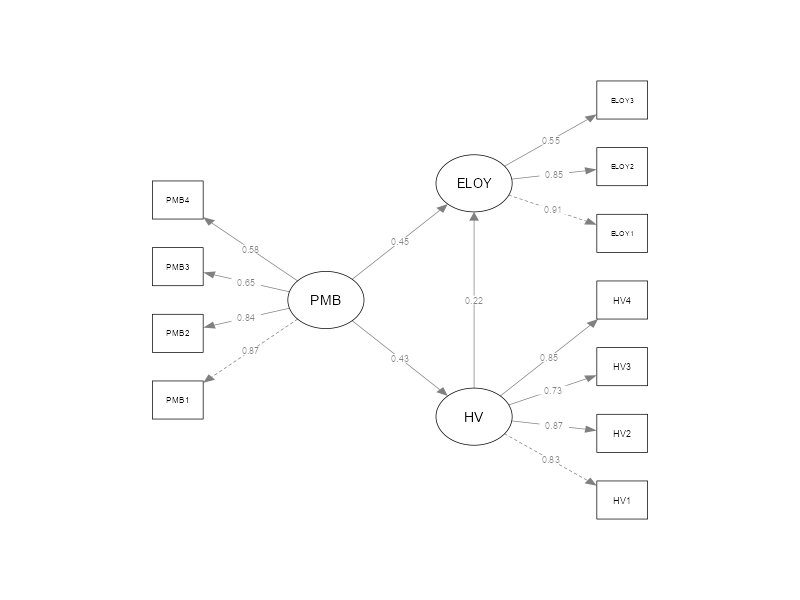

In [15]:
semPaths(sem_fit,
         whatLabels = "std",
         layout = "tree2",
         edge.label.cex = 0.8,
         style = "lisrel",
         residuals = FALSE,
         rotation = 2,
         nCharNodes = 4,
         sizeMan = 6,
         sizeLat = 9)

### Referensi CB-SEM

- Anderson, J.C. & Gerbing, D.W. (1988). Structural equation modeling in practice. *Psychological Bulletin*, 103(3), 411–423.
- Fornell, C. & Larcker, D.F. (1981). Evaluating SEM with unobserved variables. *Journal of Marketing Research*, 18(1), 39–50.
- Hu, L. & Bentler, P.M. (1999). Cutoff criteria for fit indexes. *Structural Equation Modeling*, 6(1), 1–55.
- Khoa, B.T. & Nguyen, H.M. (2020). Electronic loyalty in social commerce. *Gadjah Mada International Journal of Business*, 22(3), 275–299.
- Lee, C.-H. & Wu, J.J. (2017). Consumer online flow experience. *Industrial Management & Data Systems*, 117(10), 2452–2467.
- Nguyen, M.H. & Khoa, B.T. (2019). Perceived mental benefit in electronic commerce. *Sustainability*, 11(23), 6587–6608.

---

# Bagian B: PLS-SEM dengan seminr

## 5. Persiapan

In [19]:
library(seminr)


Attaching package: ‘seminr’

The following object is masked from ‘package:purrr’:

    rerun



### Mengapa PLS-SEM?

- Tidak memerlukan asumsi distribusi normal
- Bisa menangani **sampel kecil** (>50)
- Mendukung indikator **formatif** dan **reflektif**
- Cocok untuk model yang **kompleks** dengan banyak variabel
- Fokus pada **prediksi**, bukan hanya konfirmasi teori

### Reflektif vs Formatif

- **Reflektif** (Mode A): Indikator adalah *efek* dari konstruk. Menghapus satu indikator tidak mengubah makna konstruk. Contoh: item kepuasan pelanggan.
- **Formatif** (Mode B): Indikator *membentuk* konstruk. Menghapus satu indikator mengubah makna konstruk. Contoh: SES (pendidikan + pendapatan + pekerjaan).

### Composite vs Common Factor dalam `seminr`

Paket `seminr` menyediakan dua cara mendefinisikan konstruk:

| Fungsi | Model | Penjelasan |
|--------|-------|------------|
| `composite()` | **Composite model** | Default PLS-SEM. Skor konstruk = kombinasi linear tertimbang dari indikator. Mode A (correlation weights) ≈ reflektif; Mode B (regression weights) = formatif. |
| `reflective()` | **Common factor model** | Menggunakan PLSc (consistent PLS) untuk mengoreksi bias. Hasilnya lebih mendekati CB-SEM. Gunakan jika konstruk benar-benar reflektif dan ingin konsistensi. |

Dalam praktik:

- **`composite("X", multi_items("X", 1:4))`** — cara paling umum, default Mode A
- **`composite("X", multi_items("X", 1:4), weights = mode_B)`** — untuk konstruk formatif
- **`reflective("X", multi_items("X", 1:4))`** — untuk consistent PLS (PLSc)

In [20]:
mobi <- read_excel("data/plssem/sem_mobi.xlsx")
glimpse(mobi)

Rows: 250
Columns: 24
$ CUEX1 <dbl> 7, 10, 7, 7, 8, 10, 9,…
$ CUEX2 <dbl> 7, 10, 7, 10, 7, 9, 6,…
$ CUEX3 <dbl> 6, 9, 7, 5, 10, 7, 2, …
$ CUSA1 <dbl> 6, 10, 8, 10, 10, 8, 8…
$ CUSA2 <dbl> 4, 10, 7, 10, 8, 7, 8,…
$ CUSA3 <dbl> 7, 8, 7, 10, 8, 7, 8, …
$ CUSCO <dbl> 7, 10, 6, 5, 5, 8, 7, …
$ CUSL1 <dbl> 6, 10, 6, 10, 10, 10, …
$ CUSL2 <dbl> 5, 2, 2, 4, 3, 3, 6, 7…
$ CUSL3 <dbl> 6, 10, 7, 10, 8, 10, 8…
$ IMAG1 <dbl> 7, 10, 8, 10, 10, 8, 8…
$ IMAG2 <dbl> 5, 9, 7, 10, 10, 9, 7,…
$ IMAG3 <dbl> 5, 10, 6, 5, 5, 10, 1,…
$ IMAG4 <dbl> 5, 10, 4, 5, 8, 8, 7, …
$ IMAG5 <dbl> 4, 9, 7, 10, 9, 9, 7, …
$ PERQ1 <dbl> 7, 10, 7, 8, 10, 9, 7,…
$ PERQ2 <dbl> 6, 9, 8, 10, 9, 10, 8,…
$ PERQ3 <dbl> 4, 10, 5, 10, 8, 9, 9,…
$ PERQ4 <dbl> 7, 10, 7, 8, 10, 10, 7…
$ PERQ5 <dbl> 6, 9, 8, 4, 9, 8, 8, 7…
$ PERQ6 <dbl> 5, 10, 7, 5, 9, 9, 7, …
$ PERQ7 <dbl> 5, 10, 7, 8, 8, 9, 8, …
$ PERV1 <dbl> 2, 10, 7, 5, 6, 10, 5,…
$ PERV2 <dbl> 3, 10, 7, 5, 6, 10, 7,…


### Konstruk dan Indikator

Model ini sengaja dirancang untuk **mendemonstrasikan berbagai tipe konstruk** yang tersedia di `seminr`:

| Konstruk | Indikator | Tipe | Penjelasan |
|----------|-----------|------|------------|
| **Image** | IMAG1–3 | `composite()` Mode A | Composite reflektif (default) |
| **Value** | PERV1–2 | `composite()` Mode A | Composite reflektif |
| **Satisfaction** | — (HOC) | `higher_composite()` | Higher-Order Construct dari Image & Value |
| **Quality** | PERQ1–3 | `composite()` Mode B | Composite **formatif** |
| **Complaints** | CUSCO | `composite()` single item | Single-item construct |
| **Loyalty** | CUSL1–3 | `reflective()` | Common factor (PLSc/consistent PLS) |

::: {.callout-tip}
## Mengapa Model Ini?

Model ini bukan model ECSI standar — sengaja disederhanakan agar peserta bisa melihat **cara kerja setiap tipe konstruk** dalam satu model:

- **`composite()` Mode A** — cara paling umum, default
- **`composite()` Mode B** — untuk konstruk formatif (indikator membentuk konstruk)
- **`reflective()`** — consistent PLS (PLSc), hasilnya mendekati CB-SEM
- **`higher_composite()`** — Higher-Order Construct (HOC), Satisfaction dibentuk dari dimensi Image dan Value
- **`single_item()`** — konstruk dengan satu indikator saja
:::

### Hipotesis

| No | Hipotesis | Path |
|----|-----------|------|
| H1 | Quality → Satisfaction | Satisfaction ~ Quality |
| H2 | Satisfaction → Complaints | Complaints ~ Satisfaction |
| H3 | Satisfaction → Loyalty | Loyalty ~ Satisfaction |

Model ini juga memungkinkan pengujian mediasi: Quality → Satisfaction → Loyalty.

## 7. Spesifikasi & Estimasi Model

### Measurement Model

In [39]:
mm <- constructs(
  composite("Image",        multi_items("IMAG", 1:3)),
  composite("Value",        multi_items("PERV", 1:2)),
  higher_composite("Satisfaction",
                   dimensions = c("Image", "Value"),
                   method = two_stage),
  composite("Quality",      multi_items("PERQ", 1:3), weights = mode_B),
  composite("Complaints",   single_item("CUSCO")),
  reflective("Loyalty",     multi_items("CUSL", 1:3))
)

Perhatikan perbedaan tipe konstruk:

- **Image & Value**: `composite()` default (Mode A, correlation weights) — paling umum
- **Quality**: `composite(..., weights = mode_B)` — formatif, regression weights
- **Loyalty**: `reflective()` — menggunakan PLSc untuk konsistensi
- **Satisfaction**: `higher_composite()` — Higher-Order Construct, dibentuk dari dimensi Image dan Value menggunakan metode **two-stage**
- **Complaints**: `single_item()` — satu indikator saja

### Structural Model

In [40]:
sm <- relationships(
  paths(from = "Quality",      to = "Satisfaction"),
  paths(from = "Satisfaction", to = c("Complaints", "Loyalty"))
)

### Estimasi Model PLS

In [78]:
pls_model <- estimate_pls(
  data = as.data.frame(mobi),
  measurement_model = mm,
  structural_model = sm
)

# Workaround bug seminr: HOC dimensions perlu ada di rawdata untuk summary()
hoc_dims <- c("Image", "Value")
stage1_scores <- pls_model$first_stage_model$construct_scores
pls_model$rawdata <- cbind(pls_model$rawdata,
                           stage1_scores[, hoc_dims, drop = FALSE])

pls_summary <- summary(pls_model)

Generating the seminr model
Generating the seminr model
All 250 observations are valid.
All 250 observations are valid.


::: {.callout-warning}
Fungsi `summary()` pada seminr saat ini memiliki bug ketika model mengandung `higher_composite()` — fungsi `report_missing()` mencoba mencari kolom dimensi HOC di raw data. Sebagai workaround, kita akses komponen model secara langsung.
:::

## 8. Evaluasi Outer Model (Model Pengukuran)

### Reliabilitas

In [79]:
pls_summary$reliability

             alpha  rhoC   AVE  rhoA
Quality      0.718 0.836 0.633 1.000
Satisfaction 0.640 0.847 0.735 0.641
Complaints   1.000 1.000 1.000 1.000
Loyalty      0.472 0.580 0.368 0.715
Image        0.514 0.754 0.512 0.555
Value        0.824 0.918 0.848 0.861

Alpha, rhoC, and rhoA should exceed 0.7 while AVE should exceed 0.5

**Interpretasi:**

- **Quality** (formatif, Mode B): Alpha dan rhoA tidak relevan untuk konstruk formatif — evaluasinya menggunakan outer weights, bukan loadings/reliability.
- **Satisfaction** (HOC): rhoC = 0.847, AVE = 0.735 — memadai. Kedua dimensi (Image, Value) berkontribusi baik.
- **Complaints** (single item): Otomatis semua = 1.000.
- **Loyalty** (reflective/PLSc): Alpha = 0.472, rhoC = 0.580, AVE = 0.368 — **tidak memadai**. CUSL2 (loading 0.160) sangat rendah dan menurunkan reliabilitas.
- **Image**: Alpha = 0.514 (rendah), namun rhoC = 0.754 dan AVE = 0.512 — mendekati batas bawah.
- **Value**: Semua kriteria terpenuhi (rhoC = 0.918, AVE = 0.848).

| Kriteria | Ambang Batas | Keterangan |
|----------|-------------|------------|
| Cronbach's Alpha | ≥ 0.70 | Batas bawah reliabilitas |
| rhoC (Composite Reliability) | ≥ 0.70 | Preferensi utama untuk PLS-SEM |
| AVE | ≥ 0.50 | Convergent validity |
| rhoA | ≥ 0.70 | Konsisten untuk PLS (Dijkstra & Henseler, 2015) |

**Interpretasi**: Periksa apakah semua konstruk memenuhi ambang batas di atas. Perhatikan bahwa Complaints (single item) tidak dapat dievaluasi reliabilitasnya secara tradisional.

### Outer Loadings

In [58]:
pls_summary$loadings

      Quality Satisfaction Complaints Loyalty Image Value
Image   0.000        0.866      0.000   0.000 0.000 0.000
Value   0.000        0.848      0.000   0.000 0.000 0.000
PERQ1   0.882        0.000      0.000   0.000 0.000 0.000
PERQ2   0.673        0.000      0.000   0.000 0.000 0.000
PERQ3   0.818        0.000      0.000   0.000 0.000 0.000
CUSCO   0.000        0.000      1.000   0.000 0.000 0.000
CUSL1   0.000        0.000      0.000   0.638 0.000 0.000
CUSL2   0.000        0.000      0.000   0.160 0.000 0.000
CUSL3   0.000        0.000      0.000   0.820 0.000 0.000
IMAG1   0.000        0.000      0.000   0.000 0.832 0.000
IMAG2   0.000        0.000      0.000   0.000 0.720 0.000
IMAG3   0.000        0.000      0.000   0.000 0.569 0.000
PERV1   0.000        0.000      0.000   0.000 0.000 0.900
PERV2   0.000        0.000      0.000   0.000 0.000 0.941

**Interpretasi**: 

- Outer loading ≥ 0.70: ideal, indikator merepresentasikan konstruk dengan baik.
- Loading antara 0.40–0.70: pertimbangkan dampak penghapusan terhadap AVE dan CR. Jika penghapusan meningkatkan AVE di atas 0.50, pertimbangkan untuk menghapus.
- Loading < 0.40: sebaiknya dihapus.

### Discriminant Validity: HTMT

In [59]:
pls_summary$validity$htmt

             Quality Satisfaction Complaints Loyalty Image Value
Quality            .            .          .       .     .     .
Satisfaction   1.011            .          .       .     .     .
Complaints     0.567        0.549          .       .     .     .
Loyalty        0.866        0.947      0.561       .     .     .
Image          1.060        1.491      0.534   0.812     .     .
Value          0.667        1.177      0.387   0.797 0.720     .

**Interpretasi:** Beberapa pasangan memiliki HTMT sangat tinggi: Image–Satisfaction (1.491) dan Value–Satisfaction (1.177) — ini wajar karena Image dan Value adalah **dimensi dari HOC Satisfaction**. Satisfaction–Loyalty (0.947) dan Quality–Satisfaction (1.011) mendekati/melebihi 1.0, mengindikasikan potensi masalah discriminant validity antara konstruk-konstruk ini.

**HTMT** (Heterotrait-Monotrait Ratio, Henseler et al., 2015):

- HTMT < 0.90: memadai (threshold konservatif: < 0.85)
- Jika HTMT mendekati 1.0, kedua konstruk mungkin tidak berbeda secara empiris

### Discriminant Validity: Fornell-Larcker

In [60]:
pls_summary$validity$fl_criteria

             Quality Satisfaction Complaints Loyalty Image Value
Quality        0.796            .          .       .     .     .
Satisfaction   0.694        0.857          .       .     .     .
Complaints     0.489        0.440      1.000       .     .     .
Loyalty        0.546        0.567      0.412   0.607     .     .
Image          0.649        0.866      0.397   0.446 0.715     .
Value          0.538        0.848      0.355   0.529 0.470 0.921

FL Criteria table reports square root of AVE on the diagonal and construct correlations on the lower triangle.

**Interpretasi**: Diagonal = √AVE, off-diagonal = korelasi antar konstruk. Discriminant validity terpenuhi jika nilai diagonal > semua nilai off-diagonal pada baris/kolomnya.

### Discriminant Validity: Cross-Loadings

In [61]:
pls_summary$validity$cross_loadings

      Quality Satisfaction Complaints Loyalty Image Value
IMAG1   0.531        0.724      0.423   0.351 0.832 0.397
IMAG2   0.511        0.588      0.188   0.302 0.720 0.275
IMAG3   0.330        0.533      0.207   0.308 0.569 0.339
PERV1   0.413        0.746      0.287   0.430 0.394 0.900
PERV2   0.562        0.812      0.360   0.534 0.466 0.941
Image   0.649        0.866      0.397   0.446 1.000 0.470
Value   0.538        0.848      0.355   0.529 0.470 1.000
PERQ1   0.882        0.612      0.380   0.474 0.576 0.470
PERQ2   0.673        0.467      0.300   0.341 0.487 0.309
PERQ3   0.818        0.568      0.472   0.469 0.500 0.474
CUSCO   0.489        0.440      1.000   0.412 0.397 0.355
CUSL1   0.391        0.428      0.237   0.834 0.324 0.413
CUSL2   0.041        0.107      0.122   0.209 0.049 0.138
CUSL3   0.557        0.550      0.448   0.904 0.449 0.495

**Interpretasi**: Setiap indikator harus memiliki loading tertinggi pada konstruk miliknya sendiri dibanding konstruk lain. Jika ada indikator yang memiliki loading lebih tinggi pada konstruk lain, ini mengindikasikan masalah discriminant validity.

## 9. Bootstrap

::: {.callout-important}
## Apa yang Harus Dilakukan Jika Model PLS-SEM "Jelek"?

Berbeda dengan CB-SEM yang memiliki fit indices global, PLS-SEM dievaluasi **per komponen**. Berikut langkah perbaikan berdasarkan masalah yang ditemukan:

### 1. Reliabilitas Rendah (rhoC < 0.70 atau AVE < 0.50)

- **Periksa outer loadings** — hapus indikator dengan loading < 0.40
- Indikator dengan loading 0.40–0.70: hapus **hanya jika** penghapusan meningkatkan AVE di atas 0.50
- Jangan hapus terlalu banyak — minimal 2 indikator per konstruk reflektif

### 2. Discriminant Validity Gagal (HTMT > 0.90)

- Pertimbangkan **menggabungkan** dua konstruk yang terlalu mirip menjadi satu
- Hapus indikator yang cross-loading tinggi ke konstruk lain
- Pastikan secara konseptual konstruk memang berbeda — jika tidak, gabungkan

### 3. Outer Weight Tidak Signifikan (Konstruk Formatif/Mode B)

- Pada konstruk formatif, yang dievaluasi adalah **weight**, bukan loading
- Weight tidak signifikan belum tentu harus dihapus — periksa apakah indikator **secara konseptual penting**
- Cek multikolinearitas antar indikator formatif: VIF > 5 → pertimbangkan penghapusan atau penggabungan

### 4. R² Rendah (< 0.25)

- Tambahkan prediktor yang relevan secara teori
- Periksa apakah ada variabel mediator atau moderator yang belum dimasukkan
- R² rendah bukan berarti model salah — mungkin fenomenanya memang kompleks

### 5. Path Coefficient Tidak Signifikan

- Pastikan sudah menggunakan **bootstrap** (minimal 5000 resamples)
- Pertimbangkan apakah hubungan tersebut memang tidak ada secara empiris
- Periksa apakah ada masalah **suppression** (tanda koefisien berubah saat prediktor lain ditambahkan)

### Prinsip Umum

- **Jangan memodifikasi model hanya untuk mengejar angka bagus** — setiap perubahan harus punya dasar teori
- Laporkan model apa adanya, termasuk kelemahan — transparansi lebih dihargai daripada angka sempurna
- Gunakan **PLSpredict** (`predict_pls()` di seminr) untuk mengevaluasi kemampuan prediksi model
:::

In [63]:
set.seed(2026)
boot <- bootstrap_model(pls_model, nboot = 100, cores = 1) # nboot =100 hanya untuk demo
boot_sum <- summary(boot)

Bootstrapping model using seminr...
SEMinR Model successfully bootstrapped


::: {.callout-tip}
Gunakan minimal **nboot = 5000** untuk hasil yang stabil (Hair et al., 2019). Selalu set seed untuk reprodusibilitas.
:::

### Path Coefficients (Bootstrap)

In [64]:
boot_sum$bootstrapped_paths

                             Original Est. Bootstrap Mean
Quality  ->  Satisfaction            0.867          0.878
Satisfaction  ->  Complaints         0.549          0.544
Satisfaction  ->  Loyalty            0.838          0.853
                             Bootstrap SD T Stat. 2.5% CI
Quality  ->  Satisfaction           0.066  13.059   0.760
Satisfaction  ->  Complaints        0.075   7.306   0.390
Satisfaction  ->  Loyalty           0.096   8.692   0.665
                             97.5% CI
Quality  ->  Satisfaction       0.991
Satisfaction  ->  Complaints    0.662
Satisfaction  ->  Loyalty       1.072

**Interpretasi:** Semua 3 hipotesis **terdukung** (T > 1.96, CI tidak melewati nol). Jalur terkuat: Quality → Satisfaction (0.867, $T = 13.059$). Satisfaction → Loyalty (0.838, $T = 8.692$) dan Satisfaction → Complaints (0.549, $T = 7.306$) juga signifikan.

**Interpretasi**: Kolom `T Stat.` dan `p` menentukan signifikansi. Bootstrap confidence interval (2.5% CI dan 97.5% CI) yang tidak melewati nol mengindikasikan signifikansi pada level 5%.

Dalam PLS-SEM, bootstrap sangat penting karena signifikansi jalur tidak biasanya diandalkan dari asumsi distribusi normal, tetapi dari distribusi empiris hasil resampling.

## 10. Evaluasi Inner Model (Model Struktural)

### R² dan Path Coefficients

In [68]:
pls_summary$paths

             Satisfaction Complaints Loyalty
R^2                 0.752      0.302   0.702
AdjR^2              0.751      0.299   0.701
Quality             0.867          .       .
Satisfaction            .      0.549   0.838

**Interpretasi:** Satisfaction memiliki $R^2 = 0.752$ (substansial) — 75% variansnya dijelaskan oleh Quality. Loyalty $R^2 = 0.702$ (substansial), dan Complaints $R^2 = 0.302$ (lemah-moderat).

| R² | Interpretasi |
|-------|-------------|
| ≥ 0.75 | Substansial |
| ≥ 0.50 | Moderat |
| ≥ 0.25 | Lemah |

### Effect Size: f²

In [69]:
pls_summary$fSquare

             Quality Satisfaction Complaints Loyalty
Quality        0.000        3.035      0.000   0.000
Satisfaction   0.000        0.000      0.432   2.355
Complaints     0.000        0.000      0.000   0.000
Loyalty        0.000        0.000      0.000   0.000

**Interpretasi:** Quality → Satisfaction ($f^2 = 3.035$, sangat besar) dan Satisfaction → Loyalty ($f^2 = 2.355$, sangat besar). Satisfaction → Complaints ($f^2 = 0.432$, besar). Semua efek substantif.

| f² | Interpretasi |
|-------|-------------|
| ≥ 0.35 | Besar |
| ≥ 0.15 | Sedang |
| ≥ 0.02 | Kecil |

**Interpretasi**: f² mengukur kontribusi relatif masing-masing variabel eksogen terhadap R² variabel endogen. Nilai f² yang sangat kecil (< 0.02) menunjukkan bahwa penghapusan variabel tersebut nyaris tidak berpengaruh pada model.

## 11. Analisis Mediasi PLS-SEM

Fungsi `specific_effect_significance()` menguji signifikansi jalur spesifik — baik langsung maupun tidak langsung (mediasi) — berdasarkan bootstrap confidence interval.

### Mediasi: Quality → Satisfaction → Loyalty

In [70]:
med1 <- specific_effect_significance(boot,
  from = "Quality", through = "Satisfaction", to = "Loyalty")
med1

 Original Est. Bootstrap Mean   Bootstrap SD        T Stat. 
     0.7266103      0.7532250      0.1293329      5.6181415 
       2.5% CI       97.5% CI 
     0.5174600      1.0304410 

**Interpretasi:** Efek tidak langsung Quality → Satisfaction → Loyalty signifikan (indirect = 0.727, $T = 5.618$, 95% CI [0.517, 1.030]). Quality mempengaruhi Loyalty sepenuhnya melalui Satisfaction (karena tidak ada jalur langsung Quality → Loyalty dalam model).

### Mediasi: Quality → Satisfaction → Complaints

In [71]:
med2 <- specific_effect_significance(boot,
  from = "Quality", through = "Satisfaction", to = "Complaints")
med2

 Original Est. Bootstrap Mean   Bootstrap SD        T Stat. 
    0.47625492     0.47808021     0.07855439     6.06274138 
       2.5% CI       97.5% CI 
    0.32062412     0.62451842 

**Interpretasi:** Efek tidak langsung Quality → Satisfaction → Complaints juga signifikan (indirect = 0.476, $T = 6.063$, 95% CI [0.321, 0.625]).

## 12. Predictive Power: PLSpredict

**PLSpredict** (Shmueli et al., 2019) mengevaluasi kemampuan prediksi model menggunakan **cross-validation** (k-fold). Ini menjawab pertanyaan: *"Seberapa baik model memprediksi data baru?"*

Kriteria evaluasi — bandingkan RMSE PLS-SEM vs LM (Linear Model/regresi biasa):

| Kondisi | Interpretasi |
|---------|-------------|
| Semua $Q^2_{predict} > 0$ | Model lebih baik dari rata-rata (benchmark naif) |
| PLS-SEM RMSE < LM RMSE (semua indikator) | Predictive power **tinggi** |
| PLS-SEM RMSE < LM RMSE (mayoritas indikator) | Predictive power **sedang** |
| PLS-SEM RMSE < LM RMSE (minoritas indikator) | Predictive power **rendah** |
| PLS-SEM RMSE ≥ LM RMSE (semua indikator) | Model **tidak** memiliki predictive power |

In [ ]:
# PLSpredict belum mendukung higher_composite()
# Berikut contoh sintaks untuk model tanpa HOC:
#
# set.seed(2026)
# pred <- predict_pls(pls_model, technique = predict_DA, noFolds = 10)
# pred_sum <- summary(pred)
# pred_sum

# Demo dengan model sederhana tanpa HOC
mm_simple <- constructs(
  composite("Quality",      multi_items("PERQ", 1:3), weights = mode_B),
  composite("Satisfaction", multi_items("IMAG", 1:3)),
  composite("Complaints",   single_item("CUSCO")),
  reflective("Loyalty",     multi_items("CUSL", 1:3))
)
sm_simple <- relationships(
  paths(from = "Quality",      to = "Satisfaction"),
  paths(from = "Satisfaction", to = c("Complaints", "Loyalty"))
)
pls_simple <- estimate_pls(data = as.data.frame(mobi),
                           measurement_model = mm_simple,
                           structural_model = sm_simple)

set.seed(2026)
pred <- predict_pls(pls_simple, technique = predict_DA, noFolds = 10)
pred_sum <- summary(pred)
pred_sum

**Interpretasi:**

- **PLS vs LM RMSE (out-of-sample)**: Bandingkan baris RMSE pada "PLS out-of-sample" vs "LM out-of-sample". Jika PLS RMSE ≤ LM RMSE, model PLS memiliki predictive power yang baik.
- Pada contoh ini, PLS RMSE sedikit lebih tinggi dari LM pada semua indikator — menunjukkan predictive power **rendah** untuk model sederhana ini.
- **Construct-level**: Kolom `overfit` menunjukkan selisih IS vs OOS — nilai kecil (< 0.05) menandakan model tidak overfitting.

::: {.callout-note}
`predict_pls()` belum mendukung model dengan `higher_composite()`. Untuk model utama kita (yang mengandung HOC Satisfaction), PLSpredict tidak dapat dijalankan. Ini merupakan keterbatasan seminr saat ini.
:::

## 13. Path Diagram PLS

In [72]:
plot(pls_model)
save_plot("plsem.png")

<grViz HTML widget HTML Widget>

### Referensi PLS-SEM

- Hair, J.F., Risher, J.J., Sarstedt, M. & Ringle, C.M. (2019). When to use and how to report PLS-SEM. *European Business Review*, 31(1), 2–24.
- Henseler, J., Ringle, C.M. & Sarstedt, M. (2015). A new criterion for assessing discriminant validity. *Journal of the Academy of Marketing Science*, 43(1), 115–135.
- Tenenhaus, M., Vinzi, V.E., Chatelin, Y.-M. & Lauro, C. (2005). PLS path modeling. *Computational Statistics & Data Analysis*, 48(1), 159–205.

---

# Rekap Sesi 3

### Perbandingan Praktis

| Aspek | CB-SEM (`lavaan`) | PLS-SEM (`seminr`) |
|-------|-------------------|---------------------|
| Sintaks model | Text formula (`=~`, `~`) | `constructs()`, `relationships()` |
| Estimasi | `cfa()` / `sem()` | `estimate_pls()` |
| Signifikansi | Langsung dari output | `bootstrap_model()` |
| Fit indices | CFI, TLI, RMSEA, SRMR | $R^2$, $f^2$, HTMT |
| Visualisasi | `semPaths()` | `plot()` |
| Mediasi | Label + `:=` | `specific_effect_significance()` |

### Yang Sudah Dipelajari

- **Konsep SEM**: variabel laten vs manifes, measurement vs structural model
- **CB-SEM** dengan `lavaan`: two-step approach (CFA → Full SEM), fit indices, CR, AVE, Fornell-Larcker, mediasi bootstrap
- **PLS-SEM** dengan `seminr`:
  - Berbagai tipe konstruk: `composite()` Mode A & B, `reflective()` (PLSc), `higher_composite()`, `single_item()`
  - Outer model: loadings, reliabilitas, HTMT, cross-loadings
  - Inner model: path coefficients, $R^2$, $f^2$
  - Bootstrap & mediasi

---

# Latihan

## Latihan 1: CB-SEM

Hapus satu path dari model struktural CB-SEM (misalnya hapus path `ELOY ~ HV`) dan estimasi ulang. Bandingkan fit indices dan path coefficients dengan model asli.

In [ ]:
#| code-fold: true
#| code-summary: "Jawaban"
sem_model2 <- '
  PMB  =~ PMB1 + PMB2 + PMB3 + PMB4
  HV   =~ HV1 + HV2 + HV3 + HV4
  ELOY =~ ELOY1 + ELOY2 + ELOY3
  HV   ~ PMB
  ELOY ~ PMB
'
sem_fit2 <- sem(sem_model2, data = dat)
fitMeasures(sem_fit2, c("cfi", "tli", "rmsea", "srmr"))

  cfi   tli rmsea  srmr 
0.742 0.654 0.216 0.124 

## Latihan 2: PLS-SEM

Coba hapus indikator CUSL2 (yang loadingnya sangat rendah) dari konstruk Loyalty, kemudian estimasi ulang model. Apakah reliabilitas Loyalty membaik?

In [ ]:
#| code-fold: true
#| code-summary: "Jawaban"
mm2 <- constructs(
  composite("Image",        multi_items("IMAG", 1:3)),
  composite("Value",        multi_items("PERV", 1:2)),
  higher_composite("Satisfaction",
                   dimensions = c("Image", "Value"),
                   method = two_stage),
  composite("Quality",      multi_items("PERQ", 1:3), weights = mode_B),
  composite("Complaints",   single_item("CUSCO")),
  reflective("Loyalty",     c("CUSL1", "CUSL3"))  # Hapus CUSL2
)
pls_model2 <- estimate_pls(
  data = as.data.frame(mobi),
  measurement_model = mm2,
  structural_model = sm
)
# Workaround HOC
stage1 <- pls_model2$first_stage_model$construct_scores
for (d in c("Image", "Value")) {
  pls_model2$rawdata[[d]] <- stage1[, d]
}
summary(pls_model2)$reliability

 Original Est. Bootstrap Mean 
   0.009735994    0.011747401 
  Bootstrap SD        T Stat. 
   0.017461265    0.557576705 
       2.5% CI       97.5% CI 
  -0.018063854    0.052094999 